In [1]:
import numpy as np
# import pandas as pd
import matplotlib.pyplot as plt
import pickle
from pathlib import Path

def load_pkl(filename):
    with open(filename, 'rb') as f:
        data = pickle.load(f)
    results = data['results']
    # Newer pkls store metadata under a 'metadata' key; older ones merge it
    # at the top level. Support both.
    if 'metadata' in data and isinstance(data['metadata'], dict):
        metadata = data['metadata']
    else:
        metadata = {k: v for k, v in data.items() if k != 'results'}
    print(f"Loaded {filename}")
    print(f"  Grid: {len(metadata.get('taus', []))} x {len(metadata.get('tau_primes', []))}")
    print(f"  T={metadata.get('T')}, N={metadata.get('N')}")
    return results, metadata


In [2]:
# Load the latest grid sweep pkl
import glob
candidates = (
    sorted(glob.glob("grid_sweep_7methods_*.pkl")) +
    sorted(glob.glob("grid_sweep_11methods_*.pkl"))
)
assert candidates, "no grid_sweep_*methods_*.pkl found in cwd"
pkl_path = candidates[-1]
results, meta = load_pkl(pkl_path)
print(f"  methods in pkl: {meta.get('methods', list(next(iter(results.values())).keys()))}")


Loaded grid_sweep_11methods_20260508_171817.pkl
  Grid: 5 x 5
  T=60, N=15
  methods in pkl: ['multiframe', 'multiframe_3outcome', 'multiframe_unknown_family', 'bt_laplace_bald', 'bt_laplace_bald_k', 'bt_laplace_bald_random', 'bt_laplace_bald_lex', 'bt_mog', 'bt_hitandrun', 'bt_hitandrun_random', 'bt_hitandrun_lex']


In [3]:
# # Full grid: stacked fraction bars with global tau/tau' axes
# from collections import Counter

# taus = meta['taus']
# tau_primes = meta['tau_primes']
# N = meta['N']

# response_types = ['left', 'right', 'indifferent', 'incomparable']
# methods = ['multiframe', 'bt_laplace_bald_k', 'bt_laplace_bald_random']
# method_labels = {
#     'multiframe': 'Utilize',
#     'bt_laplace_bald_k': 'Ignore',
#     'bt_laplace_bald_random': 'Force',
# }
# response_colors = {
#     'left':         '#0072B2', 'right':         '#D55E00',
#     'indifferent':         '#F0E442', 'incomparable':         '#009E73',
# }

# n_rows = len(tau_primes)
# n_cols = len(taus)
# fig, axes = plt.subplots(n_rows, n_cols, figsize=(1.8 * n_cols + 1.2, 1.4 * n_rows + 1.0),
#                          sharex=True, sharey=True)

# for i, tau_prime in enumerate(tau_primes):
#     for j, tau in enumerate(taus):
#         ax = axes[n_rows - 1 - i, j]
#         cell = results.get((tau, tau_prime), {})

#         x = np.arange(len(methods))

#         for m_idx, m in enumerate(methods):
#             rc = cell[m]['response_counts']
#             if m == 'bt_laplace_bald_k':
#                 counts = [rc.get(r, 0) for r in ['left', 'right']]
#                 types_used = ['left', 'right']
#             else:
#                 counts = [rc.get(r, 0) for r in response_types]
#                 types_used = response_types

#             total = sum(counts)
#             fracs = [c / total if total > 0 else 0 for c in counts]

#             bottom = 0
#             for frac, rtype in zip(fracs, types_used):
#                 ax.bar(m_idx, frac, bottom=bottom, width=0.7,
#                        color=response_colors[rtype])
#                 bottom += frac

#         ax.set_ylim([0, 1.05])
#         ax.tick_params(labelsize=5)

#         if n_rows - 1 - i == n_rows - 1:  # bottom row
#             ax.set_xticks(x)
#             ax.set_xticklabels([method_labels[m] for m in methods], fontsize=6)
#         else:
#             ax.tick_params(labelbottom=False)

#         if j == 0:
#             ax.set_ylabel(f"τ'={tau_prime}", fontsize=7)
#         else:
#             ax.tick_params(labelleft=False)

#         if n_rows - 1 - i == 0:  # top row
#             ax.set_title(f"τ={tau}", fontsize=7)

# fig.suptitle('Avg Response Distribution per Oracle', fontsize=10, y=0.98)
# fig.text(0.5, 0.92, 'τ (indifference threshold)', ha='center', fontsize=9)
# fig.text(0.02, 0.5, "τ' (incomparability threshold)", va='center',
#          rotation='vertical', fontsize=9)

# handles = [plt.Rectangle((0, 0), 1, 1, color=response_colors[r]) for r in response_types]
# fig.legend(handles, [r.capitalize() for r in response_types],
#            loc='lower center', ncol=4, fontsize=7, frameon=False,
#            bbox_to_anchor=(0.5, -0.02))

# plt.tight_layout(rect=[0.04, 0.03, 1, 0.93])
# plt.show()

In [4]:
# # Bottom and top rows: stacked fraction bars with global tau/tau' axes
# from collections import Counter

# taus = meta['taus']
# tau_primes_plot = [meta['tau_primes'][0], meta['tau_primes'][-1]]
# N = meta['N']

# response_types = ['left', 'right', 'indifferent', 'incomparable']
# methods_to_plot = ['multiframe', 'bt_laplace_bald_k', 'bt_laplace_bald_random']
# method_labels = {
#     'multiframe': 'Utilize',
#     'bt_laplace_bald_k': 'Ignore',
#     'bt_laplace_bald_random': 'Force',
# }
# response_colors = {
#     'left':         '#0072B2', 'right':         '#D55E00',
#     'indifferent':         '#F0E442', 'incomparable':         '#009E73',
# }

# n_rows = len(tau_primes_plot)
# n_cols = len(taus)
# fig, axes = plt.subplots(n_rows, n_cols, figsize=(1.8 * n_cols + 1.2, 1.4 * n_rows + 1.0),
#                          sharex=True, sharey=True)

# for row_idx, tp in enumerate(tau_primes_plot):
#     ax_row = 1 - row_idx  # flip so tau' increases upward
#     for j, tau in enumerate(taus):
#         ax = axes[ax_row, j]
#         cell = results.get((tau, tp), {})

#         x = np.arange(len(methods_to_plot))

#         for m_idx, m in enumerate(methods_to_plot):
#             rc = cell[m]['response_counts']
#             if m == 'bt_laplace_bald_k':
#                 counts = [rc.get(r, 0) for r in ['left', 'right']]
#                 types_used = ['left', 'right']
#             else:
#                 counts = [rc.get(r, 0) for r in response_types]
#                 types_used = response_types

#             total = sum(counts)
#             fracs = [c / total if total > 0 else 0 for c in counts]

#             bottom = 0
#             for frac, rtype in zip(fracs, types_used):
#                 ax.bar(m_idx, frac, bottom=bottom, width=0.7,
#                        color=response_colors[rtype])
#                 bottom += frac

#         ax.set_ylim([0, 1.05])
#         ax.tick_params(labelsize=5)

#         if ax_row == n_rows - 1:  # bottom row
#             ax.set_xticks(x)
#             ax.set_xticklabels([method_labels[m] for m in methods_to_plot], fontsize=6)
#         else:
#             ax.tick_params(labelbottom=False)

#         if j == 0:
#             ax.set_ylabel(f"τ'={tp}", fontsize=7)
#         else:
#             ax.tick_params(labelleft=False)

#         if ax_row == 0:  # top row
#             ax.set_title(f"τ={tau}", fontsize=7)

# fig.suptitle('Avg Response Distribution per Oracle', fontsize=10, y=0.98)
# fig.text(0.5, 0.92, 'τ (indifference threshold)', ha='center', fontsize=9)
# fig.text(0.02, 0.5, "τ' (incomparability threshold)", va='center',
#          rotation='vertical', fontsize=9)

# handles = [plt.Rectangle((0, 0), 1, 1, color=response_colors[r]) for r in response_types]
# fig.legend(handles, [r.capitalize() for r in response_types],
#            loc='lower center', ncol=4, fontsize=7, frameon=False,
#            bbox_to_anchor=(0.5, -0.02))

# plt.tight_layout(rect=[0.04, 0.03, 1, 0.93])
# plt.show()

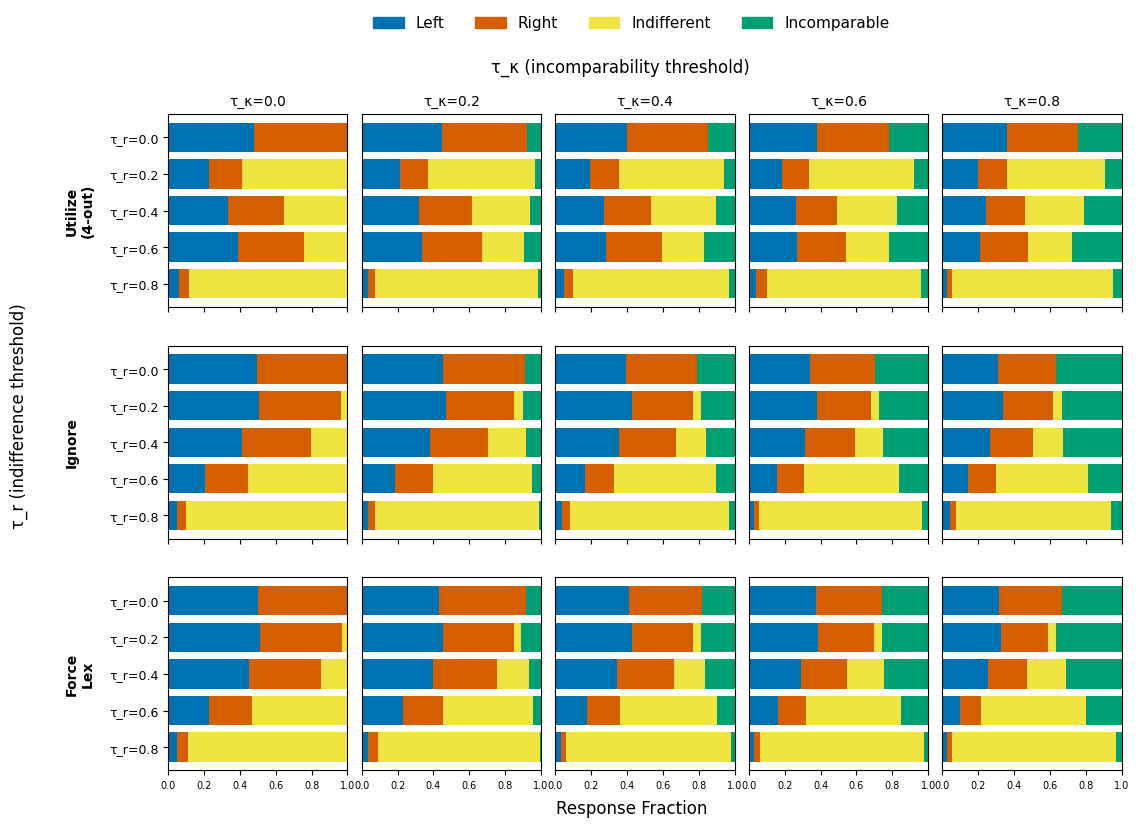

In [12]:
# Response distribution grid: methods (rows) x tau' (cols), horizontal stacked bars per tau
# Uses RAW oracle responses (response_counts), so all 4 outcomes are shown for every method —
# even Ignore-Indecision and Force-Decision, where indecisive responses still emerge from the
# oracle but get dropped or forced post-hoc by the learner.
taus = meta['taus']
tau_primes = meta['tau_primes']

all_methods = [
    'multiframe',
    # 'multiframe_3outcome',
    # 'multiframe_unknown_family',
    # 'bt_mog',
    'bt_hitandrun',
    # 'bt_hitandrun_random',
    'bt_hitandrun_lex',
]
# Keep only methods that exist in this pkl
sample_cell = next(iter(results.values()))
all_methods = [m for m in all_methods if m in sample_cell]

method_labels = {
    'multiframe':                'Utilize\n(4-out)',
    'multiframe_3outcome':       'Utilize\n(3-out)',
    'multiframe_unknown_family': 'Utilize\n(no NF)',
    'bt_mog':                    'Ignore\n(no NF)',
    'bt_hitandrun':              'Ignore\n',
    'bt_hitandrun_random':       'Force\nRandom',
    'bt_hitandrun_lex':          'Force\nLex',
}

response_types = ['left', 'right', 'indifferent', 'incomparable']
# Color-blind safe (Tol Bright + Wong)
response_colors = {
    'left':         '#0072B2',  # blue
    'right':         '#D55E00',  # rose
    'indifferent':         '#F0E442',  # sand
    'incomparable':         '#009E73',  # green
}

n_methods = len(all_methods)
n_tp = len(tau_primes)
n_tau = len(taus)

fig, axes = plt.subplots(
    n_methods, n_tp,
    figsize=(2.0 * n_tp + 1.4, 0.42 * n_tau * n_methods + 1.5),
    sharex=True,
)
if n_methods == 1:
    axes = axes.reshape(1, -1)

bar_height = 0.8

for row, method_key in enumerate(all_methods):
    for col, tp in enumerate(tau_primes):
        ax = axes[row, col]
        y_positions = np.arange(n_tau)

        for t_idx, tau in enumerate(taus):
            md = results[(tau, tp)][method_key]
            # Prefer top-level response_counts (older serial pkls). Fallback to
            # summing per-trial responses Counters (parallel pkls).
            if 'response_counts' in md:
                rc = md['response_counts']
            else:
                from collections import Counter
                rc = Counter()
                for tr in md.get('trial_results', []):
                    rc.update(tr.get('responses', {}))
            counts = [rc.get(r, 0) for r in response_types]
            total = sum(counts)
            fracs = [c / total if total > 0 else 0 for c in counts]

            left_edge = 0
            for frac, rtype in zip(fracs, response_types):
                ax.barh(t_idx, frac, left=left_edge, height=bar_height,
                        color=response_colors[rtype])
                left_edge += frac

        ax.set_xlim([0, 1.0])
        ax.set_yticks(y_positions)
        ax.invert_yaxis()
        ax.tick_params(labelsize=7)

        if col == 0:
            ax.set_yticklabels([f"τ_r={t}" for t in taus], fontsize=9)
            ax.set_ylabel(method_labels.get(method_key, method_key),
                          fontsize=10, fontweight='bold', labelpad=10)
        else:
            ax.set_yticks([])

        if row == 0:
            ax.set_title(f"τ_κ={tp}", fontsize=10)

fig.text(0.54, 0.94, "τ_κ (incomparability threshold)", ha='center', fontsize=12)
fig.text(0.005, 0.5, 'τ_r (indifference threshold)', va='center',
         rotation='vertical', fontsize=12)
fig.text(0.55, -0.01, 'Response Fraction', ha='center', fontsize=12)

handles = [plt.Rectangle((0, 0), 1, 1, color=response_colors[r]) for r in response_types]
fig.legend(handles, [r.capitalize() for r in response_types],
           loc='upper center', ncol=4, fontsize=11, frameon=False,
           bbox_to_anchor=(0.55, 1.03))

plt.tight_layout(rect=[0.04, 0.0, 1, 0.93])
plt.subplots_adjust(wspace=0.08, hspace=0.20)
plt.show()


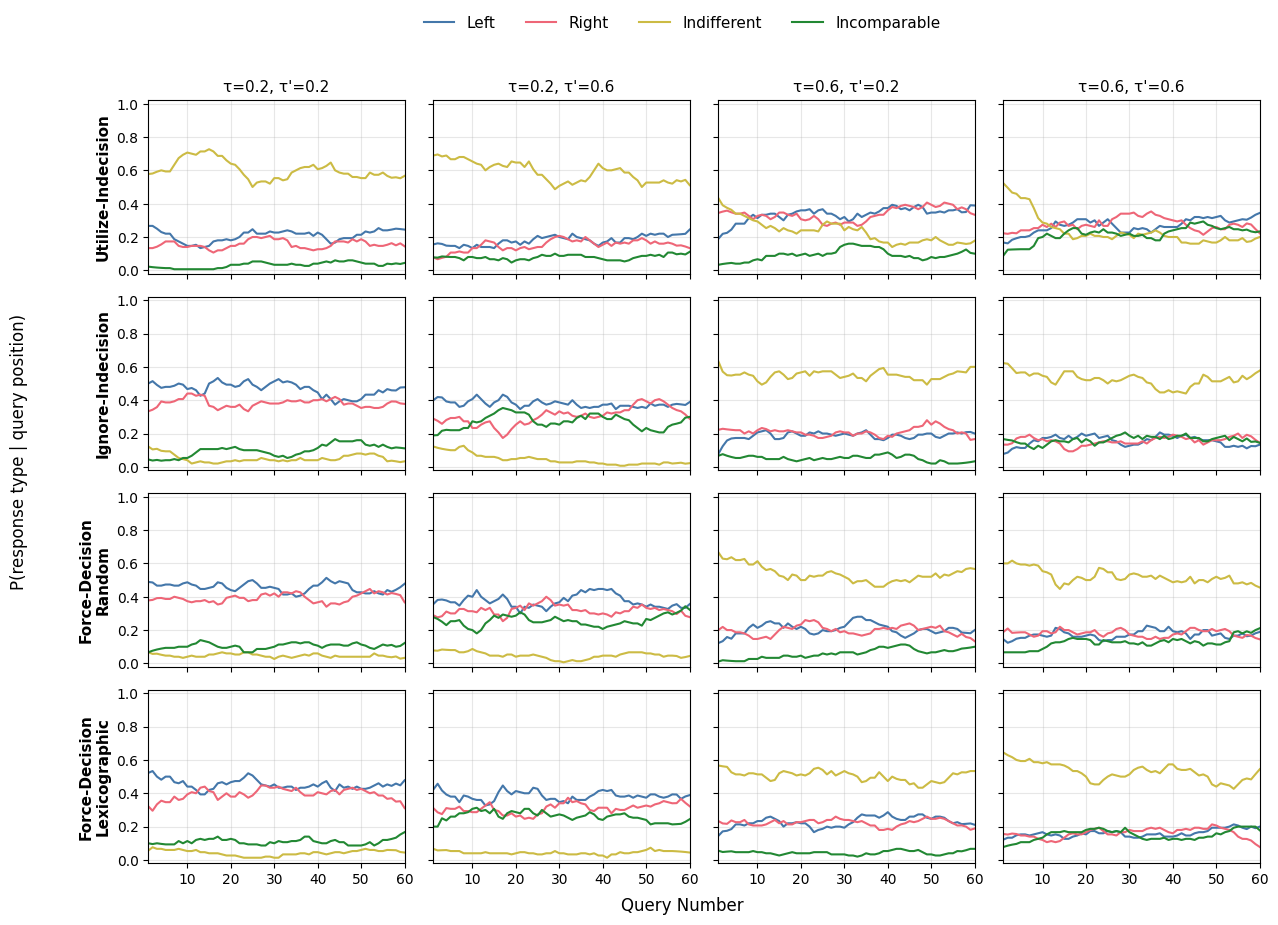

In [6]:
# Smoothed line chart: per-query response type probability over query sequence
# Grid: methods (rows) x (tau, tau') pairs (cols)
taus_plot = [0.2, 0.6]
tp_plot   = [0.2, 0.6]
pairs = [(tau, tp) for tau in taus_plot for tp in tp_plot]

T = meta['T']
window = 10

all_methods = ['multiframe', 'bt_hitandrun', 'bt_hitandrun_random', 'bt_hitandrun_lex']
sample_cell = next(iter(results.values()))
all_methods = [m for m in all_methods if m in sample_cell]

method_labels = {
    'multiframe':           'Utilize-Indecision',
    'bt_hitandrun':         'Ignore-Indecision',
    'bt_hitandrun_random':  'Force-Decision\nRandom',
    'bt_hitandrun_lex':     'Force-Decision\nLexicographic',
}

response_types = ['left', 'right', 'indifferent', 'incomparable']
response_colors = {
    'left':         '#0072B2',
    'right':         '#D55E00',
    'indifferent':         '#F0E442',
    'incomparable':         '#009E73',
}

n_methods = len(all_methods)
n_pairs = len(pairs)

fig, axes = plt.subplots(
    n_methods, n_pairs,
    figsize=(3.0 * n_pairs + 0.8, 2.0 * n_methods + 1.0),
    sharex=True, sharey=True,
)
if n_methods == 1:
    axes = axes.reshape(1, -1)

for row, method_key in enumerate(all_methods):
    for col, (tau, tp) in enumerate(pairs):
        ax = axes[row, col]
        cell = results[(tau, tp)]
        trials = cell[method_key]['trial_results']

        frac_matrix = np.zeros((len(response_types), T))

        for trial in trials:
            seq = trial['response_sequence'][:T]
            for k, resp in enumerate(seq):
                if resp in response_types:
                    r_idx = response_types.index(resp)
                    frac_matrix[r_idx, k] += 1

        trial_counts_at_k = np.zeros(T)
        for trial in trials:
            seq_len = min(len(trial['response_sequence']), T)
            trial_counts_at_k[:seq_len] += 1
        trial_counts_at_k[trial_counts_at_k == 0] = 1
        frac_matrix /= trial_counts_at_k[np.newaxis, :]

        x = np.arange(1, T + 1)

        for r_idx, r in enumerate(response_types):
            raw = frac_matrix[r_idx]
            kernel = np.ones(window) / window
            smoothed = np.convolve(raw, kernel, mode='same')
            for k in range(min(window // 2, T)):
                smoothed[k] = raw[:k + window // 2 + 1].mean()
            for k in range(max(T - window // 2, 0), T):
                smoothed[k] = raw[k - window // 2:].mean()

            ax.plot(x, smoothed, color=response_colors[r], linewidth=1.5)

        ax.set_ylim([-0.02, 1.02])
        ax.set_xlim([1, T])
        ax.tick_params(labelsize=10)
        ax.grid(True, alpha=0.3)

        if col == 0:
            ax.set_ylabel(method_labels.get(method_key, method_key),
                          fontsize=11, fontweight='bold')
        if row == 0:
            ax.set_title(f"τ={tau}, τ'={tp}", fontsize=11)

fig.text(0.53, -0.01, 'Query Number', ha='center', fontsize=12)
fig.text(0.005, 0.5, 'P(response type | query position)', va='center',
         rotation='vertical', fontsize=12)

handles = [plt.Line2D([0], [0], color=response_colors[r], linewidth=1.5)
           for r in response_types]
fig.legend(handles, [r.capitalize() for r in response_types],
           loc='upper center', ncol=4, fontsize=11, frameon=False,
           bbox_to_anchor=(0.53, 1.0))

plt.tight_layout(rect=[0.04, 0.0, 1, 0.93])
plt.show()
